In [119]:
#!pip install torch numpy pandas matplotlib scipy scikit-learn dill plotly

In [120]:
#!pip install -r /Users/20s_a02/repositories/EPDE/requirements.txt


In [127]:
import numpy as np
import pandas as pd
import dill as pickle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys, plotly
import matplotlib.pyplot as plt
from matplotlib import image
import plotly
import plotly.express as px
import torch
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import pairwise_distances
#import EPDE.epde as epde
import epde

from epde import EpdeSearch
from epde import GridTokens

from pathlib import Path
import os
import math
import re
import itertools
from pathlib import Path
from typing import List, Dict, Tuple, Any, Optional
import epde.loader as Loader
from epde import EpdeSearch
from epde.integrate import OdeintAdapter, SolverAdapter
from epde.integrate.pinn_integration import SolverAdapter


In [122]:
class DataProcessor:
    """CLASS FOR DATA PREPROCESSING"""

    def __init__(self, data: List):
        self.data = data
        self.coord_data = {}
        self.normalized_coord_data = {}

    def extract_data(self) -> Tuple[Dict, Dict]:
        """EXTRACTING RAW DATA"""
        coord_data = {}

        for inner_list in self.data:
            for item in inner_list:
                key = item[0]
                coordinates = item[2]

                if key in coord_data:
                    coord_data[key].append(coordinates)
                else:
                    coord_data[key] = [coordinates]

        self.coord_data = coord_data
        
        return coord_data

    @staticmethod
    def normalize_to_normal_distribution(data: np.ndarray) -> np.ndarray:
        if np.min(data) <= 0:
            data = data - np.min(data) + 1e-6
        transformed_data, _ = stats.boxcox(data)
        scaler = MinMaxScaler(feature_range=(0, 1))
        normalized_data = scaler.fit_transform(transformed_data.reshape(-1, 1)).flatten()
        return normalized_data

    def normalize_all_coordinates(self) -> Dict:
        """NORMALYZING DATA"""
        all_x, all_y = [], []
        for points in self.coord_data.values():
            points_array = np.array(points)
            all_x.extend(points_array[:, 0])
            all_y.extend(points_array[:, 1])
            print()
        x_normalized = self.normalize_to_normal_distribution(np.array(all_x))
        y_normalized = self.normalize_to_normal_distribution(np.array(all_y))

        idx = 0
        for obj_id, points in self.coord_data.items():
            points_array = np.array(points)
            num_points = len(points_array)
            obj_x_norm = x_normalized[idx:idx + num_points]
            obj_y_norm = y_normalized[idx:idx + num_points]
            self.normalized_coord_data[obj_id] = np.column_stack((obj_x_norm, obj_y_norm))
            idx += num_points

        return self.normalized_coord_data


In [123]:
class EquationDiscoverer:

    def __init__(self, samples: list):
        self._samples = samples

    

    def discover_system_equation(self, epde_search_obj: EpdeSearch,
                                 additional_tokens: List, dimensionality: int = 0) -> Any:
        """DISCOVERYNG SYSTEMS WITH EPDE"""
        factors_max_number = {'factors_num': [1, 2], 'probas': [0.85, 0.15]}
        # токен внешней силы 
        trig_tokens = epde.TrigonometricTokens(freq=(0.999, 1.001), dimensionality=dimensionality)
        grid_tokens = epde.GridTokens(['t'], dimensionality=dimensionality)
        epde_search_obj.fit(
            data=self._samples,
            variable_names=['x', 'y'],
            max_deriv_order=2,
            equation_terms_max_number=3,
            data_fun_pow=1,
            additional_tokens=additional_tokens+[trig_tokens, grid_tokens],
            equation_factors_max_number=factors_max_number,
            eq_sparsity_interval=(1e-10, 1)
        )

        return epde_search_obj.equations(only_print=False, only_str=False, num=2)


In [124]:
class EquationProcessor:
    """CLASS FOR ANALYZING EQUATIONS"""

    def __init__(self):
        self.regex = re.compile(r', freq:\s\d\S\d+')

    @staticmethod
    def dict_update(d_main: Dict, term: str, coeff: float, k: int) -> Dict:
        """UPDATING DICTIONARIES FOR EQUATIONS"""
        str_t = '_r' if '_r' in term else ''
        arr_term = re.sub('_r', '', term).split(' * ')

        perm_set = list(itertools.permutations(range(len(arr_term))))
        structure_added = False

        for p_i in perm_set:
            temp = " * ".join([arr_term[i] for i in p_i]) + str_t
            if temp in d_main:
                if k - len(d_main[temp]) >= 0:
                    d_main[temp] += [0 for _ in range(k - len(d_main[temp]))] + [coeff]
                else:
                    d_main[temp][-1] += coeff
                structure_added = True

        if not structure_added:
            d_main[term] = [0 for _ in range(k)] + [coeff]

        return d_main

    def equation_table(self, k: int, equation, dict_main: Dict, dict_right: Dict) -> List[Dict]:
        """CREATING EQUATION TABLES"""
        equation_s = equation.structure
        equation_c = equation.weights_final
        text_form_eq = self.regex.sub('', equation.text_form)

        flag = False
        for t_eq in equation_s:
            term = self.regex.sub('', t_eq.name)
            for t in range(len(equation_c)):
                c = equation_c[t]
                if f'{c} * {term} +' in text_form_eq:
                    dict_main = self.dict_update(dict_main, term, c, k)
                    equation_c = np.delete(equation_c, t)
                    break
                elif f'+ {c} =' in text_form_eq:
                    dict_main = self.dict_update(dict_main, "C", c, k)
                    equation_c = np.delete(equation_c, t)
                    break
            if f'= {term}' == text_form_eq[text_form_eq.find('='):] and not flag:
                flag = True
                dict_main = self.dict_update(dict_main, term, -1., k)

        return [dict_main, dict_right]

    def object_table(self, res: List, variable_names: List[str],
                     table_main: List[Dict], k: int, title: str) -> Tuple[List[Dict], int]:
        """CREATING OBJECT FOR TABLES"""

        def filter_func(*args, **kwargs):
            return True

        for list_SoEq in res:
            for SoEq in list_SoEq:
                if filter_func(SoEq, variable_names):
                    for n, value in enumerate(variable_names):
                        gene = SoEq.vals.chromosome.get(value)
                        table_main[n][value] = self.equation_table(
                            k, gene.value, *table_main[n][value]
                        )
                    k += 1
        return table_main, k

    def preprocessing_table(self, variable_name: List[str],
                            table_main: List[Dict], k: int) -> pd.DataFrame:
        """PREPROCESSING FOR CREATING DATAFRAME"""
        data_frame_total = pd.DataFrame()

        for dict_var in table_main:
            for var_name, list_structure in dict_var.items():
                general_dict = {}
                for structure in list_structure:
                    general_dict.update(structure)
                dict_var[var_name] = general_dict

        for dict_var in table_main:
            for var_name, general_dict in dict_var.items():
                for key, value in general_dict.items():
                    if len(value) < k:
                        general_dict[key] = value + [0. for _ in range(k - len(value))]

        data_frame_main = [{i: pd.DataFrame()} for i in variable_name]

        for n, dict_var in enumerate(table_main):
            for var_name, general_dict in dict_var.items():
                data_frame_main[n][var_name] = pd.DataFrame(general_dict)

        for n, var_name in enumerate(variable_name):
            data_frame_temp = data_frame_main[n].get(var_name).copy()
            list_columns = [f'{col}_{var_name}' for col in data_frame_temp.columns]
            data_frame_temp.columns = list_columns
            data_frame_total = pd.concat([data_frame_total, data_frame_temp], axis=1)

        return data_frame_total



In [34]:
def main(object_id):
    
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    # Обработка данных
    processor = DataProcessor(raw_data)
    coord_data = processor.extract_data()
    normalized_coord_data = processor.normalize_all_coordinates()

    # CHANGE OBJECT_ID FOR ANALYZING OTHER ROBOT
    #object_id = 78
    if object_id not in normalized_coord_data:
        print(f"Object ID {object_id} not found in data")
        return

    points = np.array(normalized_coord_data[object_id])
    total_points = len(points)
    cut_number = 2750
    cut_points = points[:cut_number]


    output_dir = Path('output')
    output_dir.mkdir(exist_ok=True)

    pickle_dir = output_dir / 'pickle_objects'
    pickle_dir.mkdir(exist_ok=True)

    # CUTTING FOR THREE PARTS
    part_numers = 1
    part_size = cut_number // part_numers
    boundaries = [i*part_size for i in range(part_numers+1)]

    systems_equations = []
    systems_tables = []
    equation_processor = EquationProcessor()
    variable_names = ['x', 'y']

    # CONTROLLING EACH PART
    for part_idx in range(part_numers):
        try:
            start_idx = boundaries[part_idx]
            end_idx = boundaries[part_idx + 1]

            part_points = cut_points[start_idx:end_idx]
            part_time = np.arange(len(part_points))

            x_data = part_points[:, 0]
            y_data = part_points[:, 1]
            t_data = np.arange(len(part_time))

            epde_search_obj_system = EpdeSearch(
                use_solver=False,
                boundary=10,
                coordinate_tensors=[t_data]
            )

            epde_search_obj_system.set_moeadd_params(
                population_size=10,
                training_epochs=50
            )
            
            epde_search_obj_system.set_preprocessor(
                default_preprocessor_type='poly',
                preprocessor_kwargs={'use_smoothing': True,
                                     'sigma': 50}
            )
            
            equation_system = EquationDiscoverer([x_data, y_data])

            part_equations = equation_system.discover_system_equation(
                epde_search_obj_system, additional_tokens=[], dimensionality=0
            )
          
            equation_per_level = [
                [[str(eq) for eq in solution.vals] for solution in level] 
                for level in part_equations
            ]
            print(equation_per_level)

            values_per_level = [
            [solution.obj_fun for solution in level]
                                for level in part_equations]
            for level_idx, level in enumerate(values_per_level):
                print(f"Level {level_idx}:")
                for sol_idx, obj_values in enumerate(level):
                    print(f"Solution {sol_idx}: {obj_values}")


            # Выводим для проверки
            for level_idx, level in enumerate(equation_per_level):
                print(f"Level {level_idx}:")
                for sol_idx, eq_list in enumerate(level):
                    print(f"  Solution {sol_idx}:")
                    for eq_str in eq_list:
                        print(f"    {eq_str}")


            fig = plt.figure() 
            epde_search_obj_system.visualize_solutions(dimensions=[0,1])
            plt.show()


            systems_equations.append(part_equations)

            # PREPROCESSING
            table_main = [{i: [{}, {}]} for i in variable_names]
            k = 0

            vals_flat = []
            for elem in part_equations:
                vals_flat.extend(elem)

            table_main, k = equation_processor.object_table(
                [vals_flat], variable_names, table_main, k, ''
            )
            systems_tables.append(table_main)

            print(f"\nSystem of DE {part_idx + 1} (startpoint {start_idx}-{end_idx - 1}):")
            for i, eq in enumerate(part_equations):
                print(f"EQ {i + 1}:")
                print(eq)

            # SAVE TABLE

            frame_main = equation_processor.preprocessing_table(variable_names, table_main, k)
            output_filename = f'output_smooth_{object_id}_part_{part_idx + 1}.csv'
            output_path = output_dir / output_filename
            frame_main.to_csv(output_path, sep=',', encoding='utf-8')
            print(f"Saved: {output_path}")


        except Exception as e:
            print(f"ERROR FOR part {part_idx + 1}: {e}")
            output_filename = f'output_{object_id}_part_{part_idx + 1}_0.csv'
            output_path = output_dir / output_filename
            pd.DataFrame().to_csv(output_path)
            print(f"Created empty file: {output_path}")



Processing object ID: 78 from list 30






























setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331942e10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331942e10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
2750
initial_shape (2750,) derivs_tensor.shape (2750, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
2750
initial_shape (2750,) derivs_tensor.shape (2750, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [8.77955739e-09 5.79239025e-03]
New solution accepted, confirmed 1/10 solutions.
Creating new equation, sparsity value [1.24319227e-06 1.92625362e-05]
New solution accepted, confirmed 2/10 solutions.
Creating new equation, sparsity val

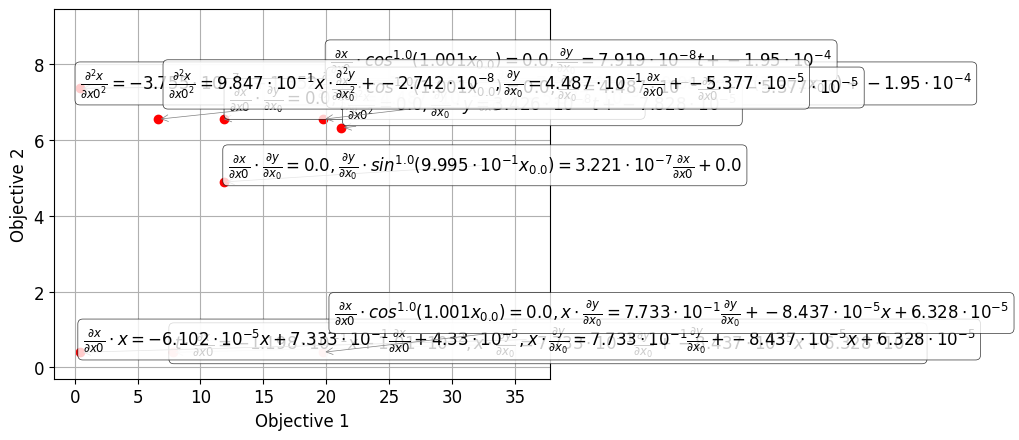


System of DE 1 (startpoint 0-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x3122dc7d0>, <epde.structure.main_structures.SoEq object at 0x311985550>, <epde.structure.main_structures.SoEq object at 0x31260fb10>, <epde.structure.main_structures.SoEq object at 0x312062b90>, <epde.structure.main_structures.SoEq object at 0x31242ee50>, <epde.structure.main_structures.SoEq object at 0x3125f4e90>, <epde.structure.main_structures.SoEq object at 0x3121fcdd0>, <epde.structure.main_structures.SoEq object at 0x312219a90>, <epde.structure.main_structures.SoEq object at 0x3122499d0>, <epde.structure.main_structures.SoEq object at 0x3125f4090>]
Saved: output/output_smooth_78_part_1.csv
Processing object ID: 74 from list 30






























setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331926d50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x331926d50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [

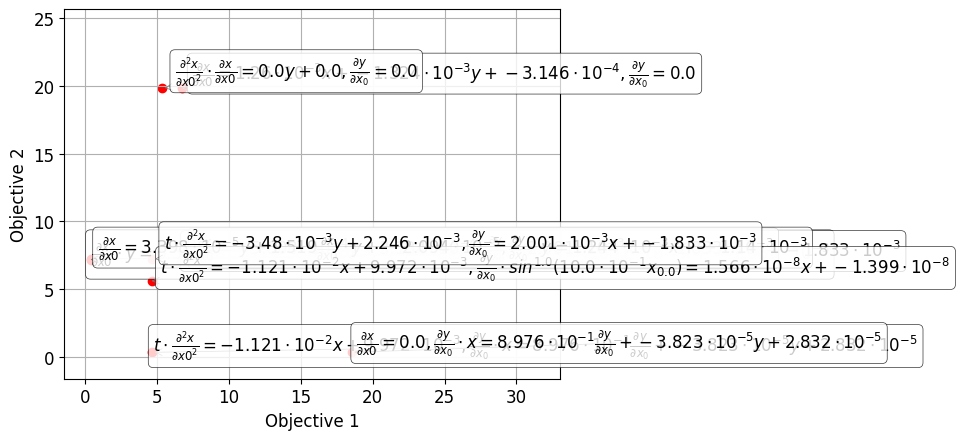


System of DE 1 (startpoint 0-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x311717090>, <epde.structure.main_structures.SoEq object at 0x311965d10>, <epde.structure.main_structures.SoEq object at 0x311e2d250>, <epde.structure.main_structures.SoEq object at 0x3119a79d0>, <epde.structure.main_structures.SoEq object at 0x311fa1d90>, <epde.structure.main_structures.SoEq object at 0x3339e45d0>, <epde.structure.main_structures.SoEq object at 0x31257c9d0>, <epde.structure.main_structures.SoEq object at 0x3339bd7d0>, <epde.structure.main_structures.SoEq object at 0x31259bfd0>, <epde.structure.main_structures.SoEq object at 0x3339e7c10>]
Saved: output/output_smooth_74_part_1.csv
Processing object ID: 28 from list 30






























setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x328219ed0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x328219ed0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [

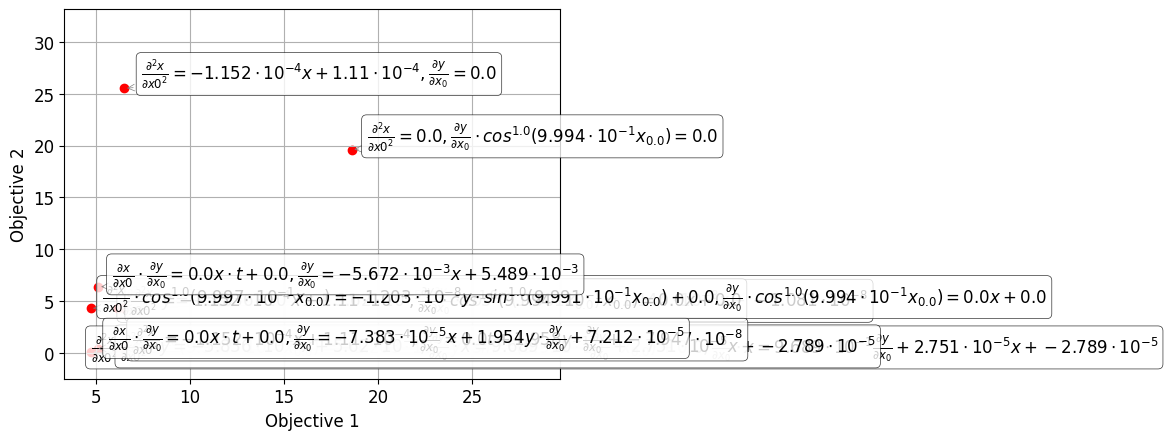


System of DE 1 (startpoint 0-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x33413c6d0>, <epde.structure.main_structures.SoEq object at 0x3340a3410>, <epde.structure.main_structures.SoEq object at 0x333e7ec50>, <epde.structure.main_structures.SoEq object at 0x334095790>, <epde.structure.main_structures.SoEq object at 0x33413c610>, <epde.structure.main_structures.SoEq object at 0x333eebb10>, <epde.structure.main_structures.SoEq object at 0x333e0d090>, <epde.structure.main_structures.SoEq object at 0x333e18350>, <epde.structure.main_structures.SoEq object at 0x333cd4490>, <epde.structure.main_structures.SoEq object at 0x3340e2a50>]
Saved: output/output_smooth_28_part_1.csv


In [ ]:
'''
if __name__ == "__main__":
    for i in [78,74,]:#robot_id:
        print(f"Processing object ID: {i} from list {len(robot_id)}")
        main(object_id=i)
'''
































 Processing robot 78 with 1 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334337150>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x334337150>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
2750
initial_shape (2750,) derivs_tensor.shape (2750, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
2750
initial_shape (2750,) derivs_tensor.shape (2750, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.97124192e-05 9.14007153e-01]
New solution accepted, confirmed 1/10 solutions.
Creating new equation, sparsity value [1.65237457e-02 2.50968032e-05]
New solution accepted, confirmed 2/10 solutions.
Creating new equation, sparsity val

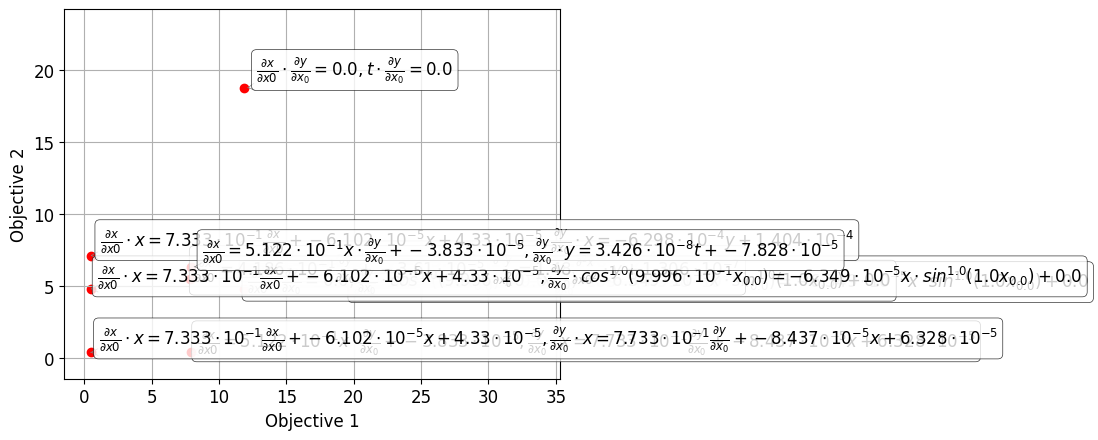


System of DE 1 (startpoint 0-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x33406c390>, <epde.structure.main_structures.SoEq object at 0x334bedbd0>, <epde.structure.main_structures.SoEq object at 0x334bcb550>, <epde.structure.main_structures.SoEq object at 0x334c64350>, <epde.structure.main_structures.SoEq object at 0x3356f64d0>, <epde.structure.main_structures.SoEq object at 0x334da4fd0>, <epde.structure.main_structures.SoEq object at 0x32f321e90>, <epde.structure.main_structures.SoEq object at 0x335737490>, <epde.structure.main_structures.SoEq object at 0x3342cb710>, <epde.structure.main_structures.SoEq object at 0x334da6050>]
Saved: output/robot_78/system_11.csv


In [125]:
# ====================
# --- MAIN PIPELINE ---
# ====================
def process_robot(object_id, normalized_coord_data, num_parts=1, output_dir=Path("output")):
    """PROCESS ONE ROBOT AND SPLIT INTO PARTS"""
    print(f"\n Processing robot {object_id} with {num_parts} parts...")

    # === Create directories ===
    robot_dir = output_dir / f"robot_{object_id}"
    robot_dir.mkdir(parents=True, exist_ok=True)

    points = np.array(normalized_coord_data[object_id])
    cut_number = min(2750, len(points))
    cut_points = points[:cut_number]

    part_size = cut_number // num_parts
    boundaries = [i * part_size for i in range(num_parts)] + [cut_number]

    for part_idx in range(num_parts):
        start_idx = boundaries[part_idx]
        end_idx = boundaries[part_idx + 1]
        part_points = cut_points[start_idx:end_idx]

        t_data = np.arange(len(part_points))
        x_data, y_data = part_points[:, 0], part_points[:, 1]

        systems_equations = []
        systems_tables = []
        equation_processor = EquationProcessor()
        variable_names = ['x', 'y']

        epde_search_obj_system = EpdeSearch(
            use_solver=False,
            boundary=10,
            coordinate_tensors=[t_data]
        )

        epde_search_obj_system.set_moeadd_params(
            population_size=10,
            training_epochs=50
        )
        
        epde_search_obj_system.set_preprocessor(
            default_preprocessor_type='poly',
            preprocessor_kwargs={'use_smoothing': True,
                                    'sigma': 50}
        )
        
        equation_system = EquationDiscoverer([x_data, y_data])

        part_equations = equation_system.discover_system_equation(
            epde_search_obj_system, additional_tokens=[], dimensionality=0
        )
        
        equation_per_level = [
            [[str(eq) for eq in solution.vals] for solution in level] 
            for level in part_equations
        ]
        print(equation_per_level)

        values_per_level = [
        [solution.obj_fun for solution in level]
                            for level in part_equations]
        for level_idx, level in enumerate(values_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, obj_values in enumerate(level):
                print(f"Solution {sol_idx}: {obj_values}")


        # Выводим для проверки
        for level_idx, level in enumerate(equation_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, eq_list in enumerate(level):
                print(f"  Solution {sol_idx}:")
                for eq_str in eq_list:
                    print(f"    {eq_str}")


        fig = plt.figure() 
        epde_search_obj_system.visualize_solutions(dimensions=[0,1])
        plt.show()


        systems_equations.append(part_equations)

        # PREPROCESSING
        table_main = [{i: [{}, {}]} for i in variable_names]
        k = 0

        vals_flat = []
        for elem in part_equations:
            vals_flat.extend(elem)

        table_main, k = equation_processor.object_table(
            [vals_flat], variable_names, table_main, k, ''
        )
        systems_tables.append(table_main)

        print(f"\nSystem of DE {part_idx + 1} (startpoint {start_idx}-{end_idx - 1}):")
        for i, eq in enumerate(part_equations):
            print(f"EQ {i + 1}:")
            print(eq)

        # SAVE TABLE

        frame_main = equation_processor.preprocessing_table(variable_names, table_main, k)
        output_path = robot_dir / f"system_{num_parts}{part_idx + 1}.csv"
        frame_main.to_csv(output_path, sep=',', encoding='utf-8')
        print(f"Saved: {output_path}")



# ==========================
# --- DISTANCE CALCULATOR ---
# ==========================
def find_closest_robots(normalized_coord_data, target_id, n_closest=2):
    """FIND NEAREST ROBOTS TO TARGET"""
    target_coord = normalized_coord_data[target_id][0]
    distances = {
        rid: np.linalg.norm(np.array(coords[0]) - target_coord)
        for rid, coords in normalized_coord_data.items() if rid != target_id
    }
    closest = sorted(distances, key=distances.get)[:n_closest]
    print(f"\n Closest to {target_id}: {closest}")
    return closest


# =====================
# --- MAIN FUNCTION ---
# =====================
def main(target_robot=78, num_parts=2, n_closest=2):
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    processor = DataProcessor(raw_data)
    processor.extract_data()
    normalized_coord_data = processor.normalize_all_coordinates()
    robots_to_process = [target_robot]
    if n_closest>0:
    # Найти ближайших роботов
        closest = find_closest_robots(normalized_coord_data, target_robot, n_closest)
        robots_to_process += closest

    output_dir = Path("output")
    for rid in robots_to_process:
        process_robot(rid, normalized_coord_data, num_parts=num_parts, output_dir=output_dir)


if __name__ == "__main__":
    main(target_robot=78, num_parts=1, n_closest=0)


In [ ]:
import pickle
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.ndimage import gaussian_filter1d

FILE_PATH = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 2

# === 1. Загрузка данных ===
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

processor = DataProcessor(data)
coord_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()

# === 5. Определение ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
distances = {
    rid: np.linalg.norm(np.array(coords[0]) - target_start)
    for rid, coords in normalized_coord_data.items() if rid != TARGET_ID
}
closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === 6. Построение траекторий ===
fig = go.Figure()
colors = ['DarkOrange', 'DarkBlue', 'DarkRed', 'YellowGreen', 'Plum']

selected_ids = [TARGET_ID] + closest_ids
for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # Линия траектории
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory {rid}'))

    # Начальная точка
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start {rid}'))

    # Конечная точка
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End {rid}'))

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.8,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)

fig.update_xaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
)
fig.update_yaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)

fig.update_xaxes(title_text="X Coordinate")
fig.update_yaxes(title_text="Y Coordinate")
fig.show()
fig.write_html("Trajectories.html")

# === 7. Дополнительно: координаты X(t), Y(t) с сглаживанием ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    t = np.arange(len(coords))
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # X(t)
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color, width=1),
                             name=f'X, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             name=f'Smooth X, robot {rid}'), row=1, col=1)

    # Y(t)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color, width=1),
                             showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             showlegend=False), row=2, col=1)

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.85,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)
fig.update_xaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey')
fig.update_xaxes(title_text="Time", row=2, col=1)
fig.update_yaxes(title_text="X Coordinate",dtick=200, row=1, col=1)
fig.update_yaxes(title_text="Y Coordinate", dtick=200, row=2, col=1)
fig.show()
fig.write_html("XY_vs_time.html")
































Ближайшие к роботу 78: [28, 74]


In [ ]:
import pickle
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.ndimage import gaussian_filter1d

FILE_PATH = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 2

# === 1. Загрузка данных ===
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

processor = DataProcessor(data)
coord_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()

# === 5. Определение ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
distances = {
    rid: np.linalg.norm(np.array(coords[0]) - target_start)
    for rid, coords in normalized_coord_data.items() if rid != TARGET_ID
}
closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === 6. Построение траекторий ===
fig = go.Figure()
colors = ['DarkOrange', 'DarkBlue', 'DarkRed', 'YellowGreen', 'Plum']

selected_ids = [TARGET_ID] + closest_ids
for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # Линия траектории
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory {rid}'))

    # Начальная точка
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start {rid}'))

    # Конечная точка
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End {rid}'))

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.8,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)

fig.update_xaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
)
fig.update_yaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)

fig.update_xaxes(title_text="X Coordinate")
fig.update_yaxes(title_text="Y Coordinate")
fig.show()
fig.write_html("Trajectories.html")

# === 7. Дополнительно: координаты X(t), Y(t) с сглаживанием ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    t = np.arange(len(coords))
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # X(t)
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color, width=1),
                             name=f'X, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             name=f'Smooth X, robot {rid}'), row=1, col=1)

    # Y(t)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color, width=1),
                             showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             showlegend=False), row=2, col=1)

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.85,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)
fig.update_xaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey')
fig.update_xaxes(title_text="Time", row=2, col=1)
fig.update_yaxes(title_text="X Coordinate",dtick=200, row=1, col=1)
fig.update_yaxes(title_text="Y Coordinate", dtick=200, row=2, col=1)
fig.show()
fig.write_html("XY_vs_time.html")
